In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, roc_auc_score, roc_curve,
                            classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
df_Fact=pd.read_excel('../Processed versions of data/Cleaned_Customer_Churn_Dataset.xlsx',sheet_name='Fact_Customer_Churn')
df_customer=pd.read_excel('../Processed versions of data/Cleaned_Customer_Churn_Dataset.xlsx',sheet_name='Dim_Customer')
df_Subscription=pd.read_excel('../Processed versions of data/Cleaned_Customer_Churn_Dataset.xlsx',sheet_name='Dim_Subscription')
df_Contract=pd.read_excel('../Processed versions of data/Cleaned_Customer_Churn_Dataset.xlsx',sheet_name='Dim_Contract')


In [3]:
df = (
    df_Fact
    .merge(df_customer, on="CustomerID", how="left")
    .merge(df_Subscription, on="Subscription Type ID", how="left")
    .merge(df_Contract, on="Contract Length ID", how="left")
)

In [4]:
df

,CustomerID,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Subscription Type ID,Contract Length ID,Age,Gender,Subscription Type,Contract Length
0,2,39,14,5,18,932.00,17,1,1,3,30,Female,Standard,Annual
1,3,49,1,10,8,557.00,6,1,2,1,65,Female,Basic,Monthly
2,4,14,4,6,18,185.00,3,1,2,2,55,Female,Basic,Quarterly
3,5,38,21,7,7,396.00,29,1,1,1,58,Male,Standard,Monthly
4,6,32,20,5,8,617.00,20,1,2,1,23,Male,Basic,Monthly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440827,449995,54,15,1,3,716.38,8,0,3,3,42,Male,Premium,Annual
440828,449996,8,13,1,20,745.38,2,0,3,3,25,Female,Premium,Annual
440829,449997,35,27,1,5,977.31,9,0,1,2,26,Male,Standard,Quarterly
440830,449998,55,14,2,0,602.55,2,0,1,2,28,Male,Standard,Quarterly


In [5]:
columns_to_drop = [
    'CustomerID',
    'Subscription Type ID',
    'Contract Length ID',
]


In [6]:
df = df.drop(columns=columns_to_drop)


In [7]:
df

,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Age,Gender,Subscription Type,Contract Length
0,39,14,5,18,932.00,17,1,30,Female,Standard,Annual
1,49,1,10,8,557.00,6,1,65,Female,Basic,Monthly
2,14,4,6,18,185.00,3,1,55,Female,Basic,Quarterly
3,38,21,7,7,396.00,29,1,58,Male,Standard,Monthly
4,32,20,5,8,617.00,20,1,23,Male,Basic,Monthly
...,...,...,...,...,...,...,...,...,...,...,...
440827,54,15,1,3,716.38,8,0,42,Male,Premium,Annual
440828,8,13,1,20,745.38,2,0,25,Female,Premium,Annual
440829,35,27,1,5,977.31,9,0,26,Male,Standard,Quarterly
440830,55,14,2,0,602.55,2,0,28,Male,Standard,Quarterly


In [8]:
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    if col != 'Churn' and col not in columns_to_drop:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

In [9]:
drop_cols = ['Churn'] + [col for col in columns_to_drop if col in df.columns]
X = df.drop(drop_cols, axis=1)
y = df['Churn']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

In [13]:
xgb_model.fit(X_train_scaled, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [14]:
y_test_pred = xgb_model.predict(X_test_scaled)
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print("Test Classification Report:")
print(classification_report(y_test, y_test_pred))
print("Test Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

Test Accuracy: 0.9994
Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     38167
           1       1.00      1.00      1.00     50000

    accuracy                           1.00     88167
   macro avg       1.00      1.00      1.00     88167
weighted avg       1.00      1.00      1.00     88167

Test Confusion Matrix:
[[38167     0]
 [   49 49951]]


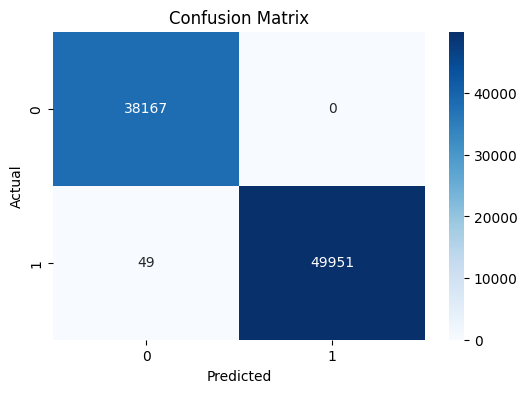

In [15]:
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

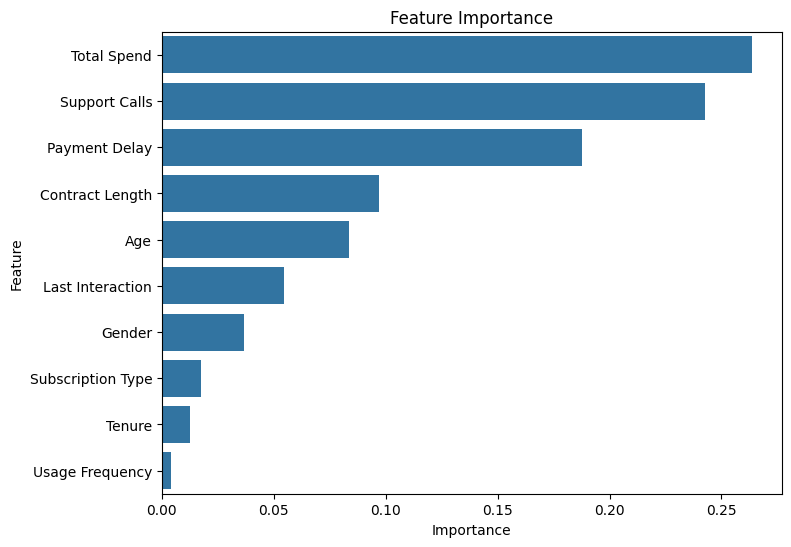

In [16]:
importance = xgb_model.feature_importances_
features = X.columns
feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importance})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df)
plt.title('Feature Importance')
plt.show()


In [17]:
import pickle
with open("model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

In [18]:
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [19]:
X_test.to_csv("X_test.csv", index=False)
y_test.to_csv("y_test.csv", index=False)


In [20]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import pickle
import plotly.graph_objects as go
import plotly.express as px
from sklearn.metrics import confusion_matrix, classification_report

# Page config
st.set_page_config(
    page_title="Customer Churn Prediction",
    page_icon="📊",
    layout="wide"
)

# Custom CSS
st.markdown("""
<style>

    div[data-testid="metric-container"] {
        background-color: white !important;
        border-radius: 12px !important;
        padding: 18px !important;
        box-shadow: 0 2px 4px rgba(0,0,0,0.15) !important;
    }

    div[data-testid="stMetricLabel"] {
        color: white !important;
        font-size: 18px !important;
        font-weight: 600 !important;
    }

    div[data-testid="stMetricValue"] {
        color: white !important;
        font-size: 26px !important;
        font-weight: 700 !important;
    }

    .main {
        background-color: #ffffff;
    }
    body, .stMarkdown, .stText {
        color: White !important;
    }

</style>
""", unsafe_allow_html=True)

# Load model + data
@st.cache_resource
def load_model():
    with open("model.pkl", "rb") as f:
        return pickle.load(f)

@st.cache_resource
def load_scaler():
    try:
        with open("scaler.pkl", "rb") as f:
            return pickle.load(f)
    except:
        st.warning("Scaler not found. Predictions might be inaccurate.")
        return None

@st.cache_data
def load_test_data():
    X_test = pd.read_csv("X_test.csv")
    y_test = pd.read_csv("y_test.csv")
    return X_test, y_test



st.title("🎯 Customer Churn Prediction System")
st.markdown("---")


with st.sidebar:
    st.header("⚙️ Navigation")
    page = st.radio("Choose a section:", ["📈 Model Performance", "🔮 Predict Churn"])
    st.markdown("---")
    st.info("💡 Tip: Use the prediction tool to assess churn risk.")

# Load model & data
try:
    model = load_model()
    scaler = load_scaler()
    X_test, y_test = load_test_data()

    if scaler is not None:
        X_test_scaled = scaler.transform(X_test)
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)
except Exception as e:
    st.error(f"Error loading files: {e}")
    st.stop()

# Page 1 — Performance
if page == "📈 Model Performance":
    st.header("📈 Model Performance Metrics")

    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="binary")
    recall = recall_score(y_test, y_pred, average="binary")
    f1 = f1_score(y_test, y_pred, average="binary")

    col1, col2, col3, col4 = st.columns(4)
    col1.metric("🎯 Accuracy", f"{accuracy:.2%}")
    col2.metric("🔍 Precision", f"{precision:.2%}")
    col3.metric("📊 Recall", f"{recall:.2%}")
    col4.metric("⚡ F1-Score", f"{f1:.2%}")

    st.markdown("---")

    col1, col2 = st.columns([1, 1])

    with col1:
        st.subheader("🔢 Confusion Matrix")
        cm = confusion_matrix(y_test, y_pred)

        fig = go.Figure(data=go.Heatmap(
            z=cm,
            x=['Predicted No', 'Predicted Yes'],
            y=['Actual No', 'Actual Yes'],
            text=cm,
            texttemplate='%{text}',
            colorscale='Blues',
            showscale=False
        ))
        fig.update_layout(height=400)
        st.plotly_chart(fig, use_container_width=True)

    with col2:
        st.subheader("📋 Classification Report")
        report = classification_report(y_test, y_pred, output_dict=True)
        df = pd.DataFrame(report).transpose()
        df = df[['precision', 'recall', 'f1-score', 'support']].round(2)
        st.dataframe(df, use_container_width=True)

# Page 2 — Prediction
else:
    st.header("🔮 Predict Customer Churn")
    st.write("Select features and enter customer information to predict churn probability:")

    subscription_options = ['Basic', 'Standard', 'Premium']
    contract_options = ['Monthly', 'Quarterly', 'Annual']

    all_columns = list(X_test.columns)

    top6 = ["Total Spend", "Support Calls", "Payment Delay",
            "Last Interaction", "Contract Length", "Gender"]

    default_features = [f for f in top6 if f in all_columns]

    selected_features = st.multiselect(
        "Select Features for Prediction",
        options=all_columns,
        default=default_features
    )

    features_to_display = list(dict.fromkeys(default_features + selected_features))

    with st.form("prediction_form"):

        user_input = {}

        cols = st.columns(3)
        for idx, feature in enumerate(features_to_display):
            with cols[idx % 3]:

                # Gender
                if feature == "Gender":
                    user_input[feature] = st.selectbox(
                        "Gender",
                        ["Male", "Female"],
                        index=0,
                        key=feature
                    )

                elif feature == "Subscription Type":
                    user_input[feature] = st.selectbox(
                        "Subscription Type",
                        subscription_options,
                        index=0,
                        key=feature
                    )

                elif feature == "Contract Length":
                    user_input[feature] = st.selectbox(
                        "Contract Length",
                        contract_options,
                        index=0,
                        key=feature
                    )

                # Numerical features
                elif np.issubdtype(X_test[feature].dtype, np.number):
                    mean_val = float(X_test[feature].mean())
                    min_val = float(X_test[feature].min())
                    max_val = float(X_test[feature].max())
                    user_input[feature] = st.number_input(
                        feature.replace('_', ' ').title(),
                        min_value=min_val,
                        max_value=max_val,
                        value=mean_val,
                        key=feature
                    )

                # Categorical other
                else:
                    options = X_test[feature].unique().tolist()
                    user_input[feature] = st.selectbox(
                        feature.replace('_', ' ').title(),
                        options,
                        index=0,
                        key=feature
                    )

        # Fill defaults for any column not displayed
        for feature in all_columns:
            if feature not in user_input:
                if feature == "Gender":
                    user_input[feature] = "Male"
                elif feature == "Subscription Type":
                    user_input[feature] = subscription_options[0]
                elif feature == "Contract Length":
                    user_input[feature] = contract_options[0]
                elif np.issubdtype(X_test[feature].dtype, np.number):
                    user_input[feature] = float(X_test[feature].mean())
                else:
                    user_input[feature] = (
                        X_test[feature].mode()[0] if not X_test[feature].mode().empty
                        else X_test[feature].iloc[0]
                    )

        submitted = st.form_submit_button("🚀 Predict Churn")

    if submitted:
        all_model_features = X_test.columns.tolist()
        full_input = {}

        for feature in all_model_features:
            if feature in user_input:
                full_input[feature] = user_input[feature]
            else:
                if feature == "Gender":
                    full_input[feature] = "Male"
                elif feature == "Subscription Type":
                    full_input[feature] = subscription_options[0]
                elif feature == "Contract Length":
                    full_input[feature] = contract_options[0]
                elif np.issubdtype(X_test[feature].dtype, np.number):
                    full_input[feature] = float(X_test[feature].mean())
                else:
                    full_input[feature] = (
                        X_test[feature].mode()[0] if not X_test[feature].mode().empty
                        else X_test[feature].iloc[0]
                    )

        input_df = pd.DataFrame([full_input])[all_model_features]

        # Encode categorical features
        if "Gender" in input_df.columns:
            input_df["Gender"] = input_df["Gender"].map({"Male": 0, "Female": 1})

        if "Subscription Type" in input_df.columns:
            input_df["Subscription Type"] = input_df["Subscription Type"].map(
                {"Basic": 0, "Standard": 1, "Premium": 2}
            )

        if "Contract Length" in input_df.columns:
            input_df["Contract Length"] = input_df["Contract Length"].map(
                {"Monthly": 0, "Quarterly": 1, "Annual": 2}
            )

        # Convert to numeric
        for col in input_df.columns:
            if np.issubdtype(X_test[col].dtype, np.number):
                input_df[col] = pd.to_numeric(input_df[col], errors="coerce")

        input_df = input_df.fillna(0)

        if scaler is not None:
            input_df_scaled = scaler.transform(input_df)
        else:
            input_df_scaled = input_df

        prediction = model.predict(input_df_scaled)[0]
        proba = model.predict_proba(input_df_scaled)[0]

        st.markdown("---")
        st.subheader("🎯 Prediction Result")

        col1, col2, col3 = st.columns(3)

        churn_prob = proba[1]

        with col1:
            if prediction == 1:
                st.error(" HIGH RISK - Customer likely to churn")
            else:
                st.success("✅ LOW RISK - Customer likely to stay")

        with col2:
            st.metric("Churn Probability", f"{churn_prob:.1%}")

        with col3:
            fig = go.Figure(go.Indicator(
                mode="gauge+number",
                value=churn_prob * 100,
                domain={'x': [0, 1], 'y': [0, 1]},
                gauge={
                    'axis': {'range': [0, 100]},
                    'bar': {'color': "darkred" if churn_prob > 0.5 else "green"},
                    'steps': [
                        {'range': [0, 50], 'color': "lightgreen"},
                        {'range': [50, 100], 'color': "lightcoral"}
                    ],
                    'threshold': {
                        'line': {'color': "red", 'width': 4},
                        'thickness': 0.75,
                        'value': 50
                    }
                }
            ))
            fig.update_layout(height=250)
            st.plotly_chart(fig, use_container_width=True)

        st.markdown("---")

        if prediction == 1:
            st.warning("### 💡 Recommended Actions:")
            st.markdown("""
            - 🎁 Offer loyalty rewards or discounts
            - 📞 Reach out with personalized communication
            - 🔍 Investigate pain points and service issues
            - 💳 Consider special retention offers
            """)
        else:
            st.info("### 💡 Recommended Actions:")
            st.markdown("""
            - 😊 Maintain current service quality
            - 📧 Continue engagement campaigns
            - ⭐ Encourage referrals and reviews
            - 🎯 Upsell relevant products/services
            """)

# Footer
st.markdown("---")
st.markdown(
    "<div style='text-align: center; color: gray;'>Analyze your customers and reduce churn risk 📊</div>",
    unsafe_allow_html=True
)


Overwriting app.py
